In [ ]:
# HEART DISEASE MACHINE LEARNING PROJECT (CLEAN VERSION)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    silhouette_score
)


# LOAD DATASET


df = pd.read_csv("heart.csv")

print("========== DATASET ==========")
print(df.head())

print("\n========== INFO ==========")
print(df.info())

print("\n========== NULL VALUES (BEFORE) ==========")
print(df.isnull().sum())

from sklearn.impute import SimpleImputer

# 1. Numeric columns
num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="mean")
df[num_cols] = imputer.fit_transform(df[num_cols])

# 2. Categorical columns (if exist)
cat_cols = df.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

print("\n========== NULL VALUES AFTER IMPUTATION ==========")
print(df.isnull().sum())


if "dataset" in df.columns:
    df = df.drop("dataset", axis=1)


# ENCODING CATEGORICAL VARIABLES


for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


# FEATURES / TARGET


X = df.drop("num", axis=1)
y = df["num"]

# Convert to binary classification
y = (y > 0).astype(int)


# STANDARDIZATION


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing completed successfully")



========== DATASET ==========
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4     


========== K-MEANS ==========
Silhouette Score : 0.1430933816959385


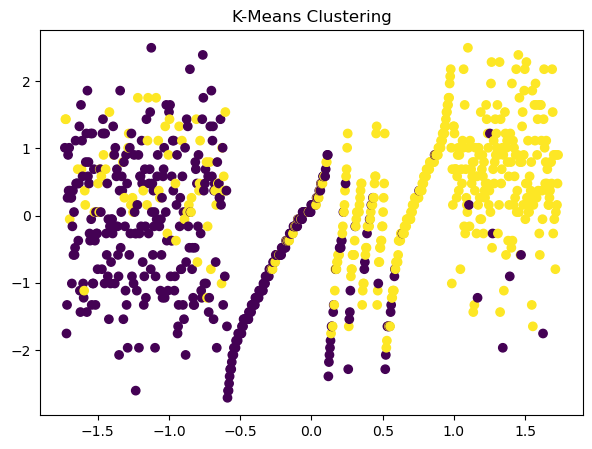

In [ ]:
# K-MEANS CLUSTERING


print("\n========== K-MEANS ==========")

kmeans = KMeans(n_clusters=2, init="k-means++", random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

silhouette = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score :", silhouette)

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()


========== HIERARCHICAL ==========


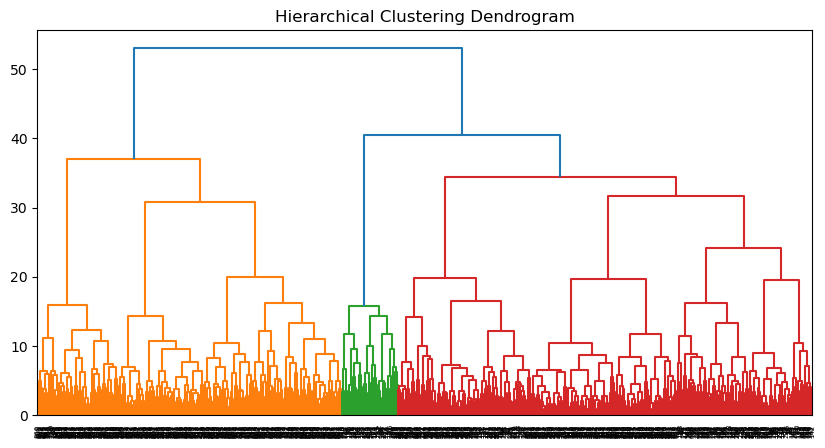

Hierarchical Clustering Done


In [ ]:
# HIERARCHICAL CLUSTERING


print("\n========== HIERARCHICAL ==========")

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(X_scaled)

print("Hierarchical Clustering Done")

In [ ]:
# DBSCAN


print("\n========== DBSCAN ==========")

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Clusters :", np.unique(db_labels))



========== DBSCAN ==========
DBSCAN Clusters : [-1  0  1  2  3  4  5  6  7  8  9 10]


In [29]:
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# DECISION TREE


print("\n========== DECISION TREE ==========")

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_accuracy)



========== DECISION TREE ==========
Decision Tree Accuracy : 0.8206521739130435


In [ ]:
# KNN

print("\n========== KNN ==========")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy :", knn_accuracy)


========== KNN ==========
KNN Accuracy : 0.8206521739130435


In [ ]:
# RANDOM FOREST


print("\n========== RANDOM FOREST ==========")

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy :", rf_accuracy)


========== RANDOM FOREST ==========
Random Forest Accuracy : 0.8913043478260869


In [ ]:
# ADABOOST


print("\n========== ADABOOST ==========")

ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)

y_pred_ab = ab.predict(X_test)
ab_accuracy = accuracy_score(y_test, y_pred_ab)

print("AdaBoost Accuracy :", ab_accuracy)



========== ADABOOST ==========
AdaBoost Accuracy : 0.8478260869565217


In [ ]:
# CLASSIFICATION REPORT


print("\n========== CLASSIFICATION REPORT (RF) ==========")
print(classification_report(y_test, y_pred_rf))


========== CLASSIFICATION REPORT (RF) ==========
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        75
           1       0.92      0.90      0.91       109

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184




========== CONFUSION MATRIX ==========


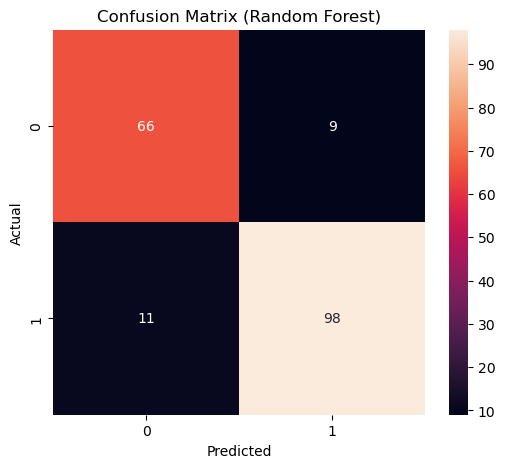

In [ ]:
# CONFUSION MATRIX


print("\n========== CONFUSION MATRIX ==========")

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


========== ROC CURVE ==========


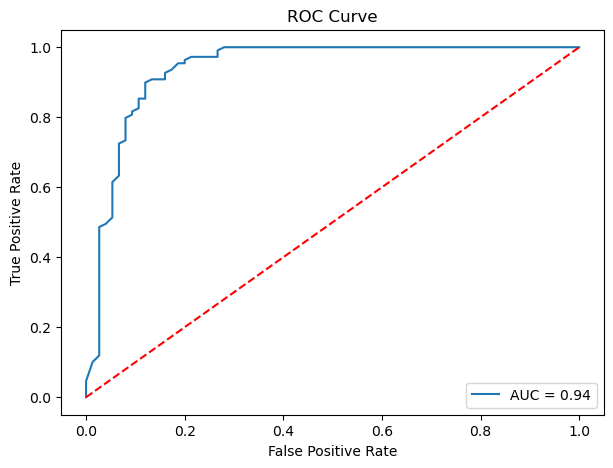

In [ ]:
# ROC CURVE


print("\n========== ROC CURVE ==========")

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:

# CROSS VALIDATION


print("\n========== CROSS VALIDATION ==========")

scores = cross_val_score(rf, X_scaled, y, cv=5, scoring="accuracy")

print("Cross Validation Scores :", scores)
print("Average Score :", scores.mean())


========== CROSS VALIDATION ==========
Cross Validation Scores : [0.69565217 0.6576087  0.95652174 0.85869565 0.60326087]
Average Score : 0.7543478260869565


In [ ]:
# FINAL COMPARISON


results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "Random Forest", "AdaBoost"],
    "Accuracy": [dt_accuracy, knn_accuracy, rf_accuracy, ab_accuracy]
})

print("\n========== MODEL COMPARISON ==========")
print(results)


# BEST MODEL


best_model = results.loc[results["Accuracy"].idxmax()]

print("\n========== BEST MODEL ==========")
print(best_model)


========== MODEL COMPARISON ==========
           Model  Accuracy
0  Decision Tree  0.820652
1            KNN  0.820652
2  Random Forest  0.891304
3       AdaBoost  0.847826

========== BEST MODEL ==========
Model       Random Forest
Accuracy         0.891304
Name: 2, dtype: object


In [ ]:

from sklearn.linear_model import LinearRegression, LogisticRegression
print("\n========== LINEAR MODELS ==========")

# 1. LINEAR REGRESSION

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lr = lin_reg.predict(X_test)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred_lr)

print("\nLinear Regression (MSE):", mse)


# 2. LOGISTIC REGRESSION 

print("\n========== LOGISTIC REGRESSION ==========")

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))



results = pd.concat([
    results,
    pd.DataFrame({
        "Model": ["Logistic Regression"],
        "Accuracy": [log_acc]
    })
], ignore_index=True)

print("\n========== UPDATED MODEL COMPARISON ==========")
print(results)

# BEST MODEL UPDATE


best_model = results.loc[results["Accuracy"].idxmax()]

print("\n========== UPDATED BEST MODEL ==========")
print(best_model)


========== LINEAR MODELS ==========

Linear Regression (MSE): 0.14326319103543875

========== LOGISTIC REGRESSION ==========
Logistic Regression Accuracy: 0.7989130434782609

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.84      0.77        75
           1       0.88      0.77      0.82       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184


========== UPDATED MODEL COMPARISON ==========
                 Model  Accuracy
0        Decision Tree  0.820652
1                  KNN  0.820652
2        Random Forest  0.891304
3             AdaBoost  0.847826
4  Logistic Regression  0.798913

========== UPDATED BEST MODEL ==========
Model       Random Forest
Accuracy         0.891304
Name: 2, dtype: object
